In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "../images/EDA/"

df = pd.read_csv("../data/raw/placement_dataset_1000.csv")

In [3]:
print(df.shape)

(1000, 15)


In [4]:
df.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           1000 non-null   int64  
 1   gender          1000 non-null   str    
 2   ssc_p           1000 non-null   float64
 3   ssc_b           1000 non-null   str    
 4   hsc_p           1000 non-null   float64
 5   hsc_b           1000 non-null   str    
 6   hsc_s           1000 non-null   str    
 7   degree_p        1000 non-null   float64
 8   degree_t        1000 non-null   str    
 9   workex          1000 non-null   str    
 10  etest_p         1000 non-null   float64
 11  specialisation  1000 non-null   str    
 12  mba_p           1000 non-null   float64
 13  status          1000 non-null   str    
 14  salary          553 non-null    float64
dtypes: float64(6), int64(1), str(8)
memory usage: 117.3 KB


In [6]:
df.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,553.000000
mean,500.500000,67.494090,66.615980,66.274670,71.846520,62.212070,294287.522604
std,288.819436,11.219919,10.781473,8.073869,13.607532,6.245209,104445.666514
min,1.000000,36.830000,35.000000,44.410000,45.620000,45.280000,200000.000000
25%,250.750000,60.545000,60.665000,61.000000,60.000000,57.685000,240000.000000
50%,500.500000,67.040000,65.525000,66.000000,70.000000,61.840000,265000.000000
75%,750.250000,76.002500,73.177500,71.752500,82.992500,66.682500,300000.000000
max,1000.000000,91.920000,100.000000,94.500000,100.000000,80.570000,940000.000000


In [7]:
# df.isnull().sum()

df.isnull().sum() / len(df) * 100

sl_no              0.0
gender             0.0
ssc_p              0.0
ssc_b              0.0
hsc_p              0.0
hsc_b              0.0
hsc_s              0.0
degree_p           0.0
degree_t           0.0
workex             0.0
etest_p            0.0
specialisation     0.0
mba_p              0.0
status             0.0
salary            44.7
dtype: float64

## Feature Distributions

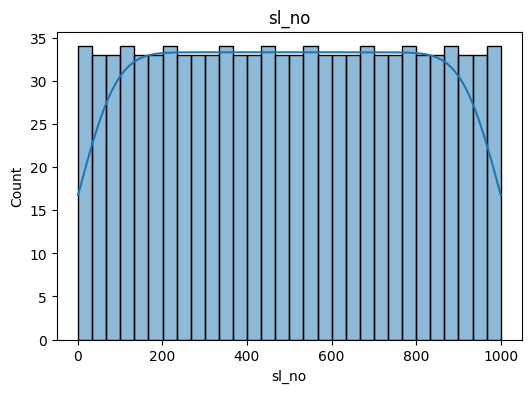

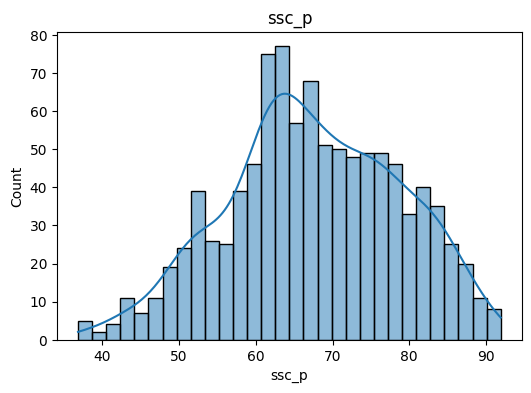

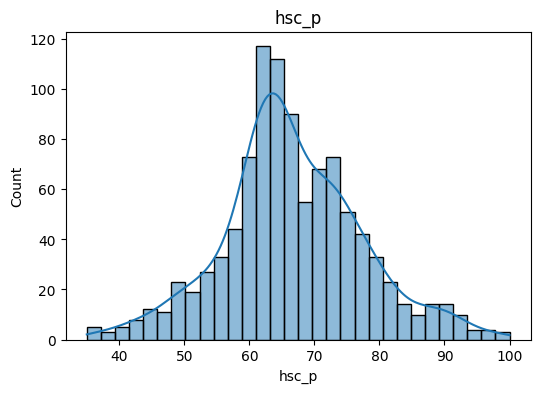

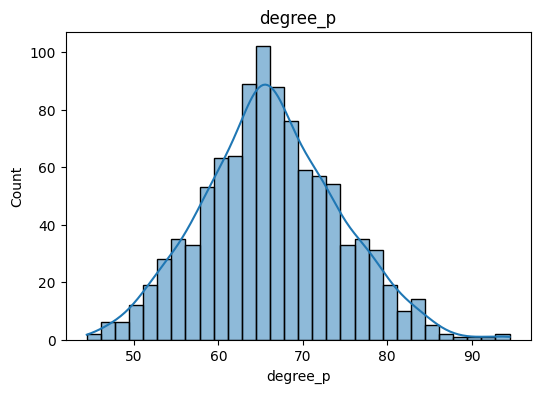

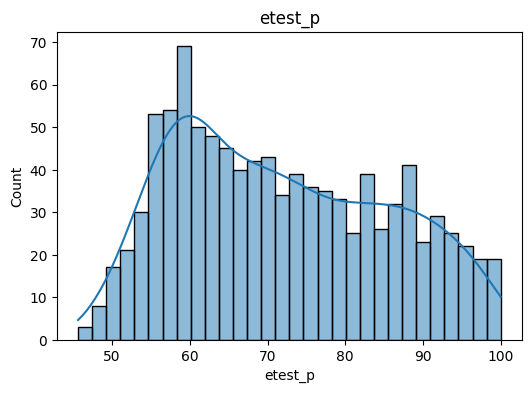

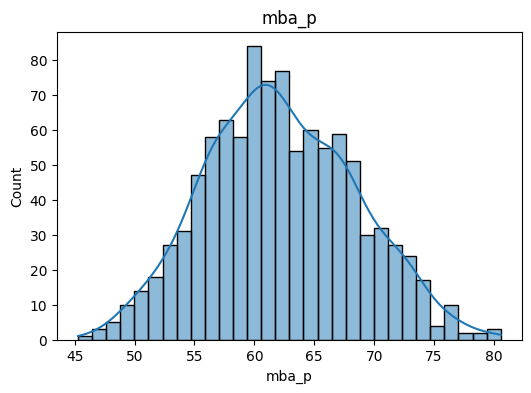

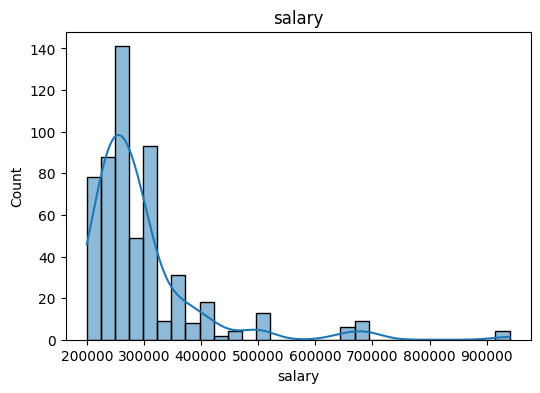

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()




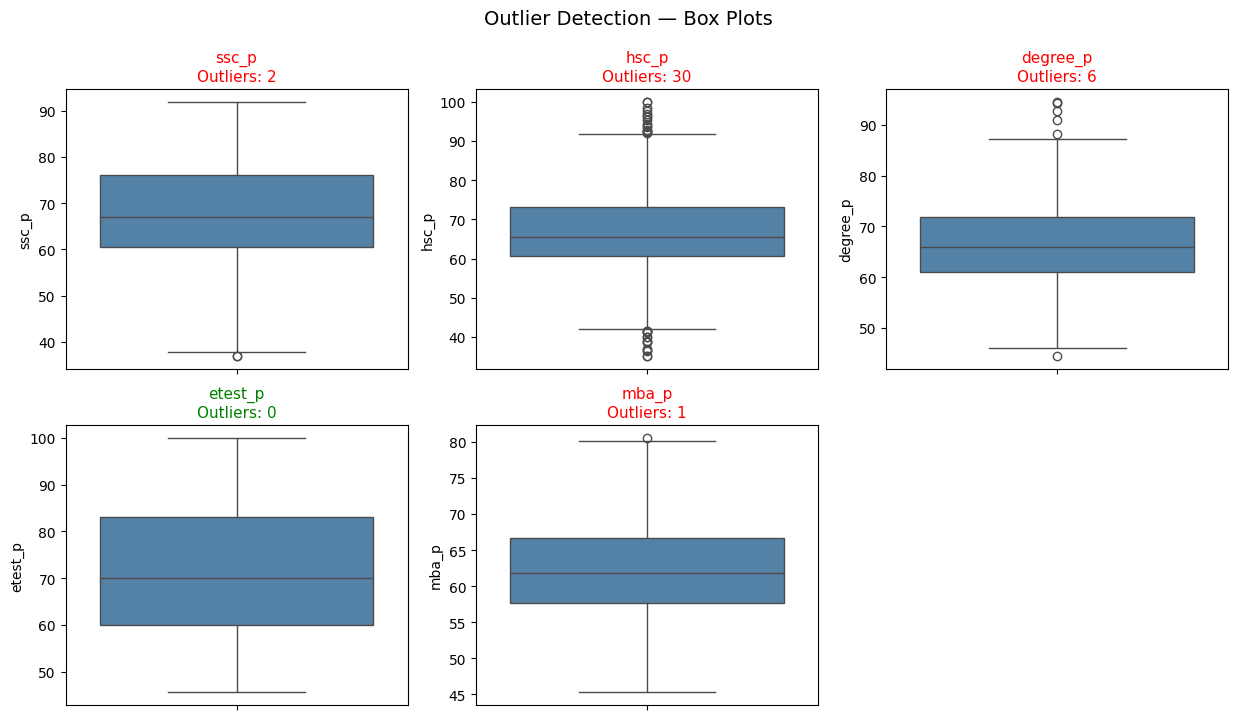

In [13]:
fig, axes = plt.subplots(2,3, figsize=(15, 8))
axes = axes.flatten()

num_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

for i, col in enumerate(num_cols):
    # Calculate outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    
    # Title with outlier count, red if outliers exist
    color = 'red' if n_outliers > 0 else 'green'
    axes[i].set_title(f'{col}\nOutliers: {n_outliers}', fontsize=11, color=color)

axes[5].set_visible(False)

plt.suptitle('Outlier Detection — Box Plots', fontsize=14)
plt.show()

## Correlation Matrix

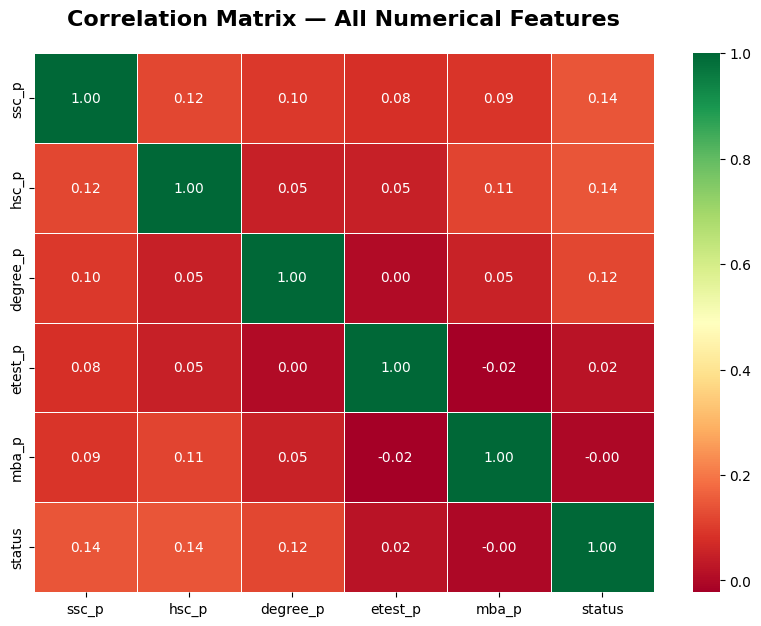

In [10]:
plt.figure(figsize=(10, 7))

# Fresh copy from original df
df_corr = df.copy()
df_corr['status'] = df_corr['status'].map({'Placed': 1, 'Not Placed': 0})

# Temporary list — don't touch num_cols
corr_cols = num_cols + ['status']
corr_matrix = df_corr[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Correlation Matrix — All Numerical Features", fontsize=16, fontweight="bold", pad=20)
plt.savefig(os.path.join(output_dir, 'correlation_matrix.png'))
plt.show()

## Target Distribution

status
Placed        553
Not Placed    447
Name: count, dtype: int64


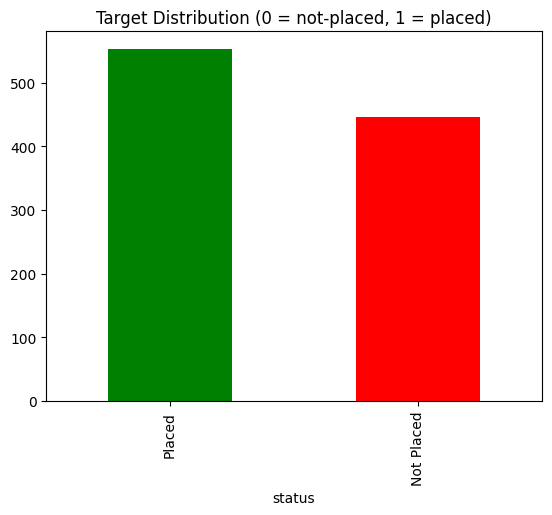

In [11]:
df['status'].value_counts().plot(kind='bar',color=['green','red'])

print(df['status'].value_counts())

plt.title('Target Distribution (0 = not-placed, 1 = placed)')
plt.savefig(os.path.join(output_dir, 'target_distribution.png'))

## Missing Values

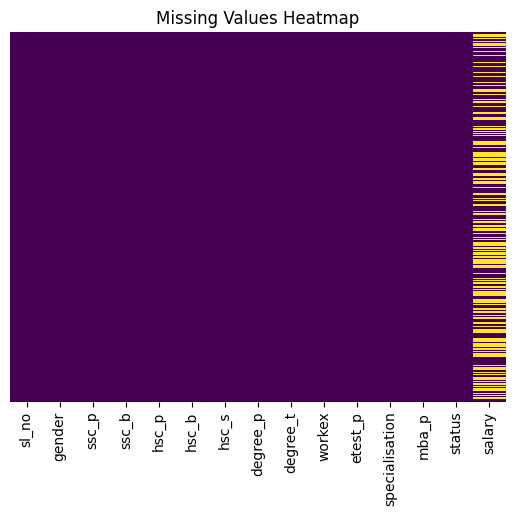

In [12]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.savefig(os.path.join(output_dir, 'missing_values_heatmap.png'))